In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, nltk, os, glob
from utils import plot_style, norm01; plot_style();
import torch

* Generate one-hot stimulus vector of stim_dim=10 per timepoint across total_time = 100
* Variables to be defined up-top: n_events = 10; event_avg_len = total_time/n_events
* Per event, stimuli should be autoregressive, i.e., directedly autocorrelated; for example
    * 10100, 10000, 00000 as event stims, where
        * event_len = event_avg_len + noise = 3 in this example
        * autoreg_feat_size[event_i] = rand number <=int(stim_dim/2) = 3 in this example because
        * autoreg_features[event_i] = rand #autoreg_feat_size indices = [0,1,2] in this example because those dimensions seem to change progressively
        * autoreg_direction[event_i] = rand(0,1) = 0 in this example because 1s become 0s
    * Thoughts? Better ways to operationalize autoregression?
* Visualize time-time stim correlation heatmap in my plotting code style

In [2]:
# Parameters
np.random.seed(42)
stim_dim      = 10
total_time    = 100
n_events      = 10
event_avg_len = total_time / n_events

# Variable event lengths with noise; last event adjusted to hit total_time exactly
event_lengths = np.random.normal(event_avg_len, event_avg_len * 0.2, n_events).astype(int)
event_lengths = np.clip(event_lengths, 5, None)
event_lengths[-1] = total_time - event_lengths[:-1].sum()

print(f"stim_dim={stim_dim}, total_time={total_time}, n_events={n_events}, event_avg_len={event_avg_len}")
print(f"event_lengths: {event_lengths}  (sum={event_lengths.sum()})")


stim_dim=10, total_time=100, n_events=10, event_avg_len=10.0
event_lengths: [10  9 11 13  9  9 13 11  9  6]  (sum=100)


In [3]:
# Per-event autoregressive metadata
autoreg_feat_size = []  # number of autoregressive features per event
autoreg_features  = []  # which feature indices are autoregressive per event
autoreg_direction = []  # 0=decay (1→0), 1=build (0→1) per event

for event_idx in range(n_events):
    n_autoreg = np.random.randint(1, int(stim_dim / 2) + 1)  # rand number <= int(stim_dim/2)
    feat_order = np.random.permutation(stim_dim)[:n_autoreg]
    autoreg_feat_size.append(n_autoreg)
    autoreg_features.append(feat_order)
    autoreg_direction.append(np.random.randint(0, 2))

autoreg_direction = np.array(autoreg_direction)

for i in range(n_events):
    label = "build (0→1)" if autoreg_direction[i] == 1 else "decay (1→0)"
    print(f"Event {i:2d}: autoreg_feat_size={autoreg_feat_size[i]}  autoreg_feats={autoreg_features[i]}  direction={label}")


Event  0: autoreg_feat_size=4  autoreg_feats=[6 2 8 7]  direction=decay (1→0)
Event  1: autoreg_feat_size=3  autoreg_feats=[1 5 4]  direction=decay (1→0)
Event  2: autoreg_feat_size=5  autoreg_feats=[5 2 4 7 9]  direction=decay (1→0)
Event  3: autoreg_feat_size=2  autoreg_feats=[8 9]  direction=build (0→1)
Event  4: autoreg_feat_size=1  autoreg_feats=[2]  direction=decay (1→0)
Event  5: autoreg_feat_size=2  autoreg_feats=[4 2]  direction=decay (1→0)
Event  6: autoreg_feat_size=5  autoreg_feats=[6 2 5 8 3]  direction=decay (1→0)
Event  7: autoreg_feat_size=5  autoreg_feats=[1 5 2 4 3]  direction=decay (1→0)
Event  8: autoreg_feat_size=1  autoreg_feats=[6]  direction=decay (1→0)
Event  9: autoreg_feat_size=4  autoreg_feats=[5 4 2 9]  direction=build (0→1)


In [4]:

# Generate stimulus matrix with autoregressive event structure
stim = np.zeros((total_time, stim_dim))
event_start_t = 0  # global timepoint where current event starts

for event_idx in range(n_events):
    event_len     = event_lengths[event_idx]
    autoreg_feats = autoreg_features[event_idx]
    stable_feats  = np.setdiff1d(np.arange(stim_dim), autoreg_feats)
    direction     = autoreg_direction[event_idx]

    # Sample event template (Bernoulli 0.5) — unique binary fingerprint for this event
    event_template = (np.random.rand(stim_dim) > 0.5).astype(float)

    for event_t in range(event_len):
        t        = event_start_t + event_t
        progress = event_t / (event_len - 1)  # ∈ [0,1]: 0 at event start, 1 at event end

        # Autoregressive features: fade from template value toward 0 (decay) or 1 (build)
        tmpl = event_template[autoreg_feats]
        if direction == 0:  stim[t, autoreg_feats] = tmpl * (1 - progress)           # toward 0
        else:               stim[t, autoreg_feats] = tmpl + (1 - tmpl) * progress    # toward 1

        # Stable features: fixed at template value for entire event
        stim[t, stable_feats] = event_template[stable_feats]

    event_start_t += event_len

print(f"stim shape : {stim.shape}")
print(f"stim range : [{stim.min():.2f}, {stim.max():.2f}]")
print(f"Total timepoints filled: {event_start_t}")


stim shape : (100, 10)
stim range : [0.00, 1.00]
Total timepoints filled: 100


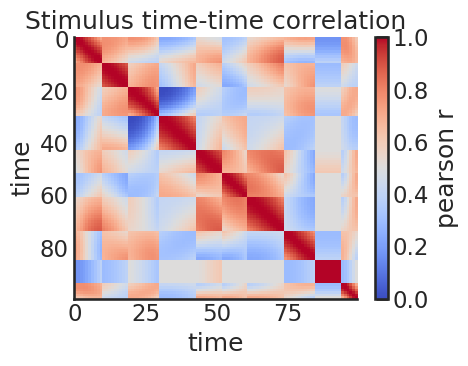

In [11]:

fig, ax = plt.subplots(figsize=(5,4))
ax.set(title='Stimulus time-time correlation', xlabel='time', ylabel='time')
im = ax.imshow(norm01(np.corrcoef(stim)), aspect='auto', cmap='coolwarm', vmin=0, vmax=1,
               origin='upper', interpolation='nearest')
plt.colorbar(im, ax=ax, label='pearson r')
plt.tight_layout()
plt.show()
